# Ejemplo de Reconstrucción 3D

In [24]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from features import find_correspondence_points
from sfm import linear_triangulation, ensure_homogeneous

In [25]:
img1_path = 'left13'
img2_path = 'right13'

img1 = cv2.imread('imgs/'+img1_path+'.JPG')
img2 = cv2.imread('imgs/'+img2_path+'.JPG')

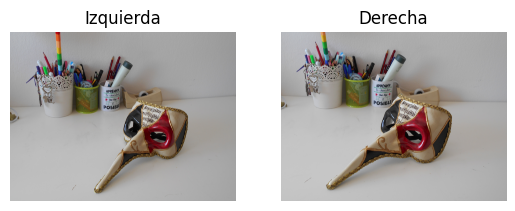

In [26]:
# Convertir a RGB
left = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
right = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 2)

axs[0].imshow(left)
axs[0].axis('off')
axs[0].set_title('Izquierda')

axs[1].imshow(right)
axs[1].axis('off')
axs[1].set_title('Derecha')

plt.show()

In [27]:
import os

if os.path.exists("keypoints/pts1-"+img1_path+".npy") and os.path.exists("keypoints/pts2-"+img2_path+".npy"):
    # Cargo los puntos homologos calculados con SIFT que han sido calculados anteriormente
    pts1 = np.load("keypoints/pts1-"+img1_path+".npy")
    pts2 = np.load("keypoints/pts2-"+img2_path+".npy")
else:
    # Usamos el algoritmo SIFT para obtener los puntos homólogos
    pts1, pts2 = find_correspondence_points(img1, img2)
    
    #Guardar los puntos
    np.save("keypoints/pts1-"+img1_path+".npy", pts1)
    np.save("keypoints/pts2-"+img2_path+".npy", pts2)

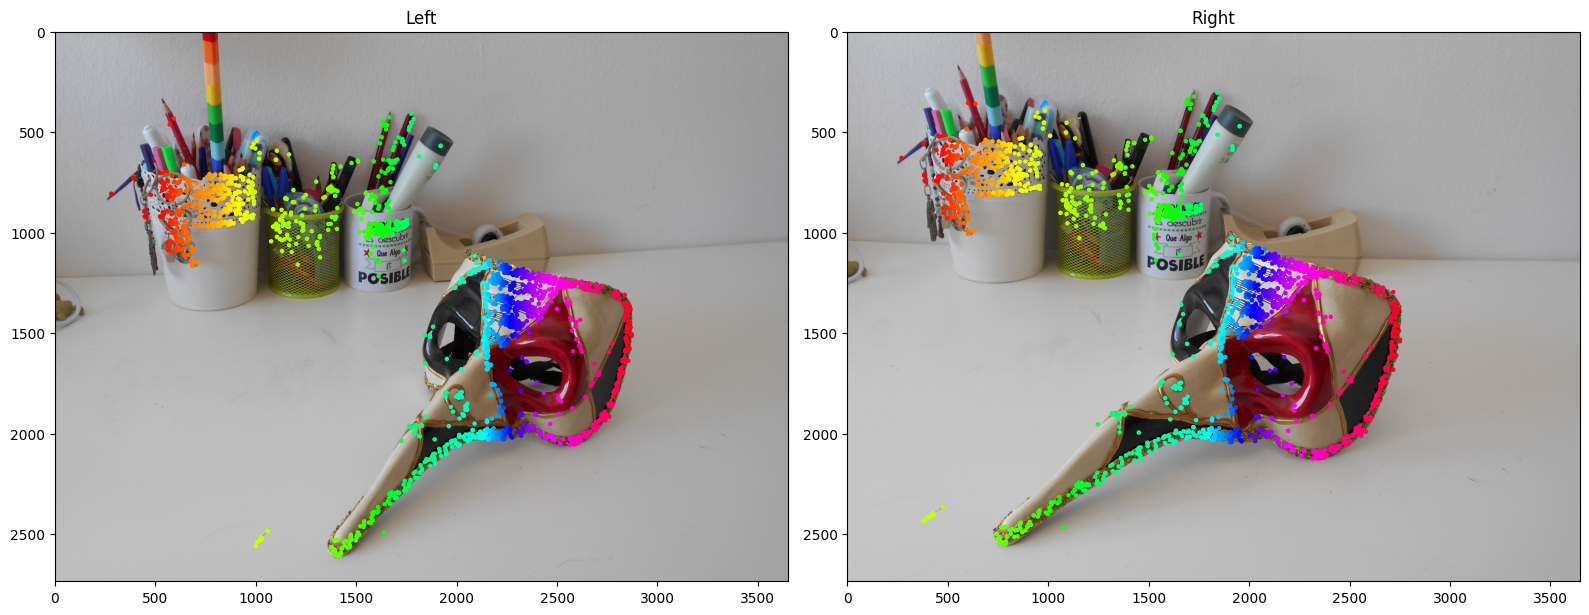

In [28]:
# Rango de puntos
start = 0
end = pts1.shape[1]

pts1_sub = pts1[:, start:end]
pts2_sub = pts2[:, start:end]

N = pts1_sub.shape[1]
#colors = np.random.rand(N,3) # Colores Aleatorios
colors = plt.cm.hsv(np.linspace(0, 1, N)) # Coores más vivos

plt.figure(figsize=(16,9))

plt.subplot(1,2,1)
plt.imshow(left)
plt.scatter(pts1_sub[0], pts1_sub[1], s=5, c=colors)
plt.title("Left")
plt.axis('on')

plt.subplot(1,2,2)
plt.imshow(right)
plt.scatter(pts2_sub[0], pts2_sub[1], s=5, c=colors)
plt.title("Right")
plt.axis('on')

plt.tight_layout()
plt.savefig('plots/keypoints_'+img1_path+'_and_'+img2_path+'.png')
plt.show()

In [35]:
K = np.load("K_matrix.npy")
P2 = np.load("P2_matrix.npy")
P2

#K = np.array([[2864.8, 0, 636.7],[0, 2864.8, 931.9],[0,0,1]])

array([[ 0.99571951, -0.06050712,  0.06986807,  1.95287436],
       [ 0.05680679,  0.99693524,  0.05378773,  0.2141431 ],
       [-0.07290849, -0.04958851,  0.99610508, -0.37473251]])

In [30]:
P1 = K @ np.vstack([np.eye(3), np.zeros((1,3))]).T

In [31]:
P2 = K @ P2

In [32]:
M = linear_triangulation(pts1, pts2, P1, P2)

In [33]:
%matplotlib inline

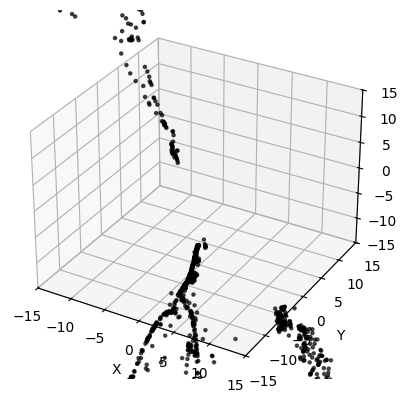

In [38]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = M[0, :]
y = M[1, :]
z = M[2, :]

ax.scatter(x, y, z, c='k', s=5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_xlim(-15, 15)
ax.set_ylim(-15, 15)
ax.set_zlim(-15, 15)

plt.show()